In [1]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [2]:
import matplotlib.pyplot as plt

In [18]:
device = 'cuda:3'

In [3]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [159]:
coords = adata.obsm[cellstate_key]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm[f"{cellstate_key}_standardized"] = coords

In [50]:
cellstate_key = "DM_EigenVectors_multiscaled"
timepoint_key = 'timepoint_tx_days'

In [29]:
timepoints = [0.5, 1.0, 1.5]

In [15]:
test_clones = ['Clone_3869' , 'Clone_2673' , 'Clone_2831']
cbs = [adata.obs.query("`timepoint_tx_days` == @t & `clones` in @test_clones").index.to_list()
            for t in adata.uns['pop']['t']]

In [16]:
test_X = [adata[cb].obsm[cellstate_key][:,:n_dimension].copy() for cb in cbs]

for X in test_X:
    print(X.shape)

(4, 5)
(65, 5)
(187, 5)


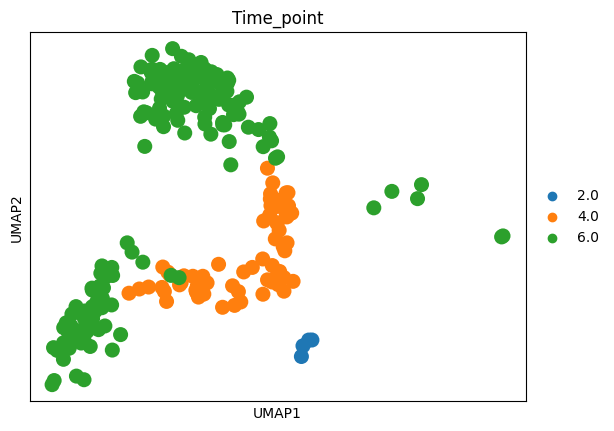

In [95]:
sc.pl.umap(
    adata[adata.obs.query("`clones` in @test_clones").index], color=['Time_point']
)

# load TIGON model

In [51]:
# git clone TIGON 
sys.path.append('/ssd/users/Wergillius/Project/TIGON')
import utility

In [ ]:
from torchcfm.conditional_flow_matching import *
from torchdyn.core import NeuralODE
from torchcfm.utils import plot_trajectories, torch_wrapper

In [44]:
from torchcfm.optimal_transport import wasserstein

In [10]:
ckpt = torch.load("logs/TIGON/model2/ckpt.pth")

In [12]:
LOSS = ckpt['LOSS']
Trans = ckpt['TRANS']
L2_1 = ckpt['L2_1']
L2_2 = ckpt['L2_2']
Sigma = ckpt['Sigma']

In [16]:
LOSS[80],LOSS[100]

(0.5170110464096069, 8.993673324584961)

In [18]:
best_checkpoint = torch.load("logs/TIGON/model2/ckpt_itr80.pth")
model_state_dict = best_checkpoint['func_state_dict']

In [ ]:
device = 'cuda:3'

func = utility.UOT(in_out_dim=n_dimension, 
           hidden_dim=16, n_hiddens=4, activation='Tanh').to(device)
func.load_state_dict(model_state_dict)

v = func.hyper_net1.to(device)
g = func.hyper_net2.to(device)

In [43]:
torch.from_numpy(test_X[0]).float().to(device).shape

torch.Size([4, 5])

In [ ]:
from torchdiffeq import odeint
from torchcfm.optimal_transport import wasserstein

In [54]:
node = NeuralODE(v, solver="dopri5", sensitivity="adjoint")

In [ ]:
with torch.no_grad():
    traj_0_1 = odeint(v,  y0 = torch.from_numpy(test_X[0]).float().to(device), 
              t = torch.linspace(0.5, 1.0, 2), method='dopri5'
              ).cpu()


wasserstein(traj_0_1[-1], torch.tensor(test_X[1]), power=2)

1.115632052657166

In [47]:
def plot_simple_traj(traj, which_dim=[0,1]):    
    n = 2000
    fig = plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.scatter(traj[0, :n, which_dim[0]], traj[0, :n, which_dim[1]], s=13, alpha=0.8, c="black", label=r"$p_0$")
    ax.scatter(traj[:, :n, which_dim[0]], traj[:, :n, which_dim[1]], s=0.2, alpha=0.2, c="olive", label=r"$p_t$")
    ax.scatter(traj[-1, :n, which_dim[0]], traj[-1, :n, which_dim[1]], s=6, alpha=1, c="blue", label= r"$p_1$")
    plt.xticks([])
    plt.yticks([])
    return fig, ax

def plot_allcells_and_trajectories(traj, which_dim=[0,1]):
    """Plot trajectories of some selected samples."""

    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.scatter(
        adata.obsm[cellstate_key][:, which_dim[0]],
        adata.obsm[cellstate_key][:, which_dim[1]],
        c=adata.obs[timepoint_key], s=0.4, alpha=0.1,
    )

    ax.scatter(traj[:, :n, which_dim[0]], traj[:, :n, which_dim[1]], s=0.4, alpha=0.1, c="olive", label= r"$p_1$")


    for i in range(15):
        ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], alpha=0.5, c="red" #, label=r"$X_t \mid X_0$"
                )

    return fig, ax

In [212]:
with torch.no_grad():
    traj_1_2 = odeint(v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(1, 1.5, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.457949849823799
W2 skh reg=0.01: 	 0.01159203084823636
W2 skh reg=0.05: 	 3.4819759527116725
W2 skh reg=1: 	 3.6565807834299573


In [222]:
with torch.no_grad():
    traj_1_2 = odeint(v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(4.0, 6.0, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.493203880399981
W2 skh reg=0.01: 	 0.001563985608908302
W2 skh reg=0.05: 	 3.516798497486617
W2 skh reg=1: 	 3.689562078316061


In [ ]:
wasserstein

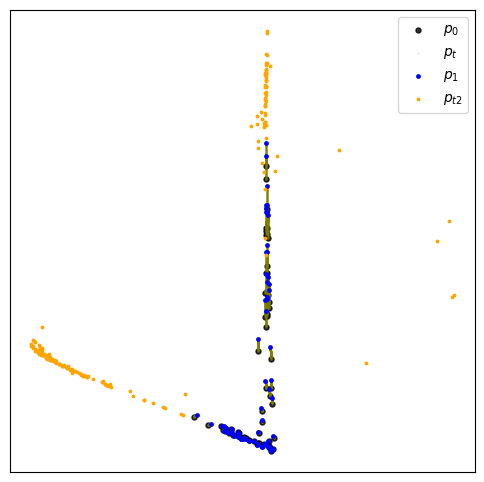

In [193]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

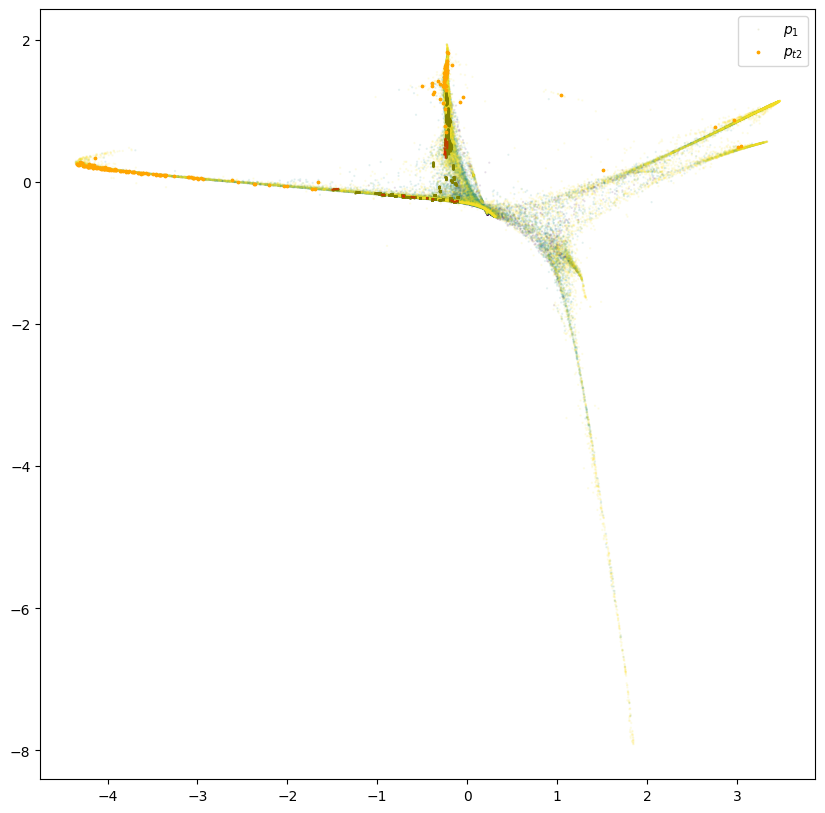

In [194]:
which_dim = [0,2]
fig, ax = plot_allcells_and_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

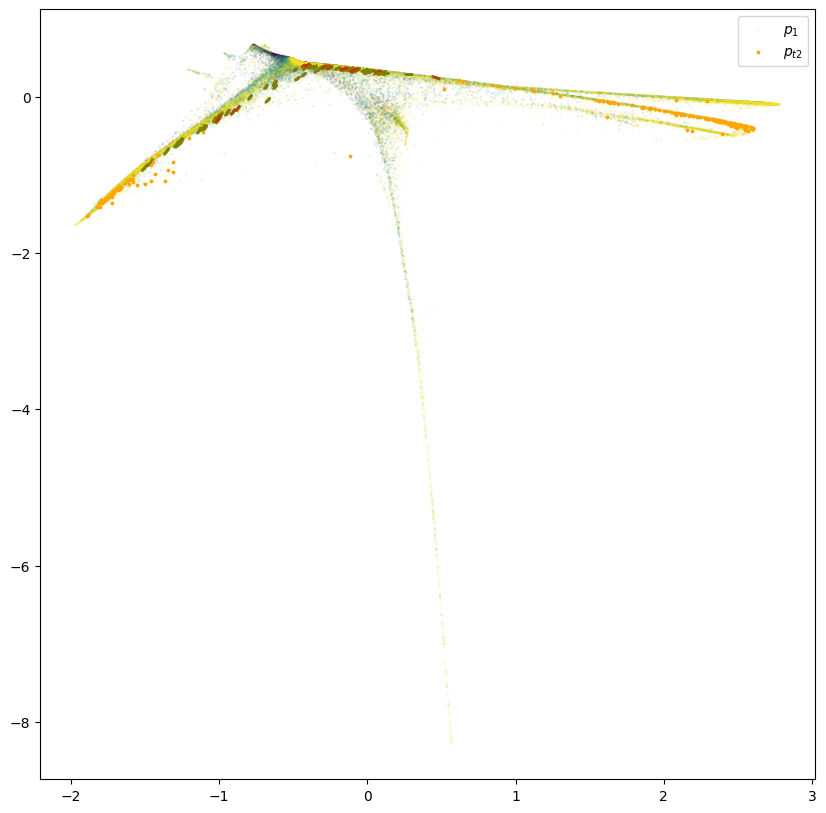

In [195]:
which_dim = [1,3]
fig, ax = plot_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

# OT_cfm model

In [217]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_ot_cfm_.pt")
ot_cfm_model = checkpoint['model'].to(device)

In [218]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(test_X[1]).float().to(device),
        t_span=torch.linspace(1, 2, 200),
    ).cpu()

print("W2: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.069594847945499
W2 skh reg=0.01: 	 0.022653652218989042
W2 skh reg=0.05: 	 3.098471623118887
W2 skh reg=1: 	 3.2898329654586917


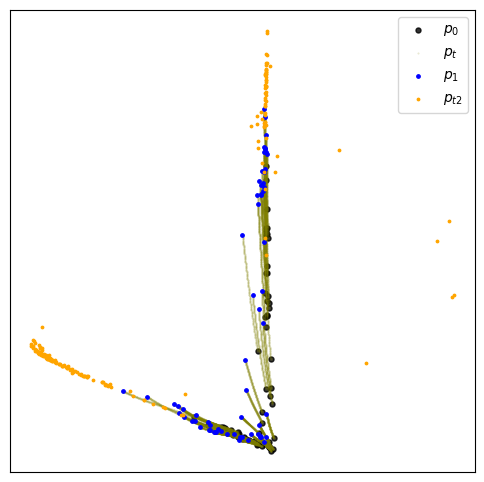

In [189]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

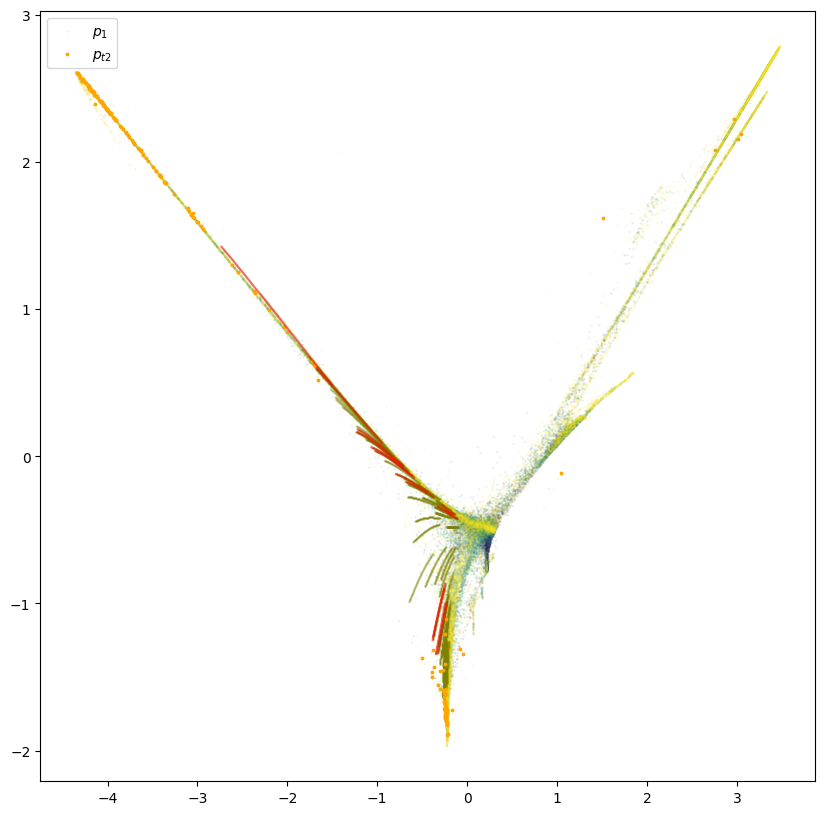

In [190]:
which_dim = [0,1]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

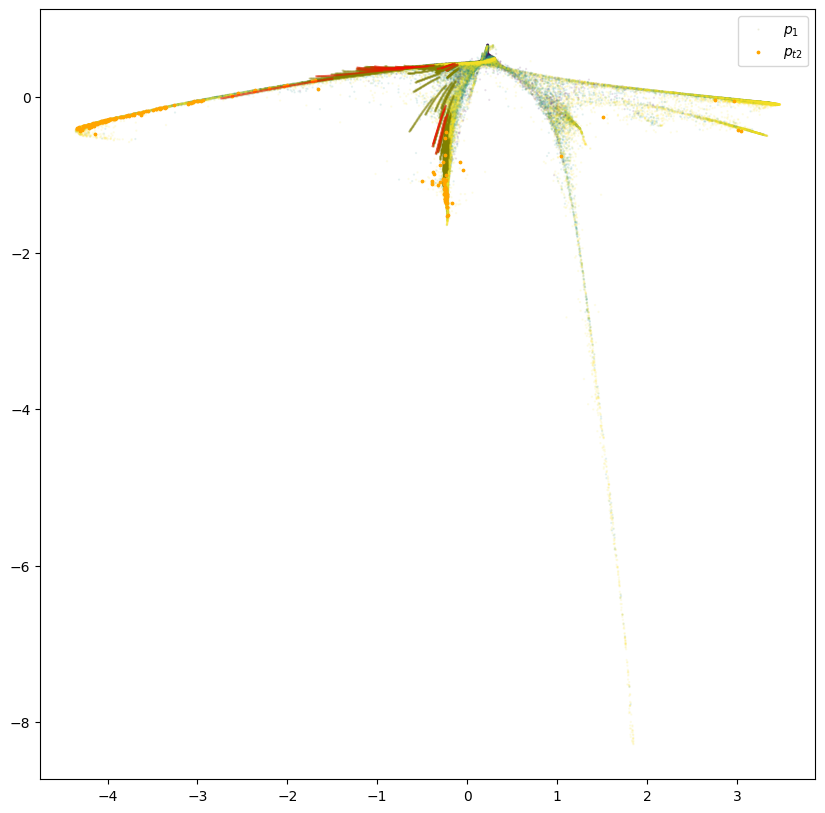

In [191]:
which_dim = [0,3]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

In [104]:
wasserstein(traj[-1], torch.tensor(test_X[1]), power=2)

1.2256528716729667

# SF2M

In [220]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_sf2m_sigma_0.25.pt")
sf2m_model = checkpoint['model'].to(device)

In [221]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(test_X[1]).float().to(device),
        t_span=torch.linspace(1, 2, 200),
    ).cpu()

print("W2: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 2.997398643204862
W2 skh reg=0.01: 	 0.02189552092846346
W2 skh reg=0.05: 	 3.026866327282345
W2 skh reg=1: 	 3.224602721316507


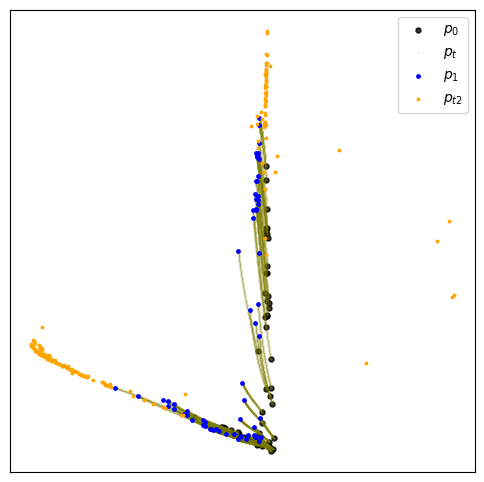

In [199]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

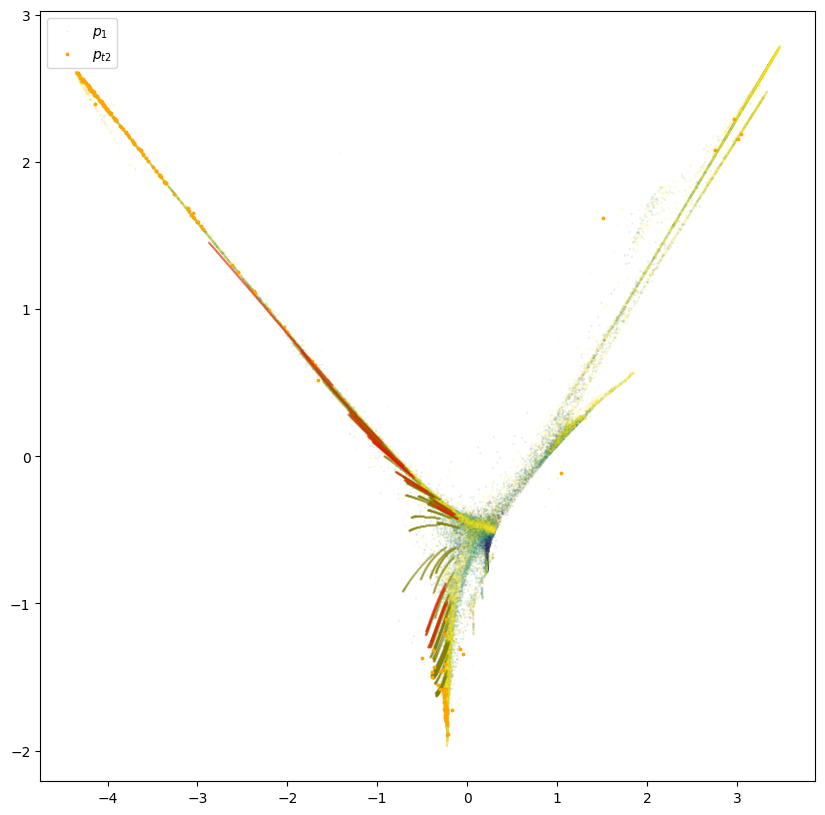

In [203]:
which_dim = [0,1]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

# PINN

In [225]:
import functools

In [228]:
from PINN import reader, models, pl, tl

In [32]:
class ODE(torch.nn.Module):
    noise_type = "diagonal"
    sde_type = "ito"

    def __init__(self, drift, ):
        super().__init__()
        self.drift = drift


    # Drift
    def forward(self, t, s):
        batch = s.shape[0]
        device = s.device
        t_in = torch.full((batch,1), t).float().to(device)

        return self.drift(s, t_in)
    

In [58]:
device = 'cuda:3'
PINN_ckpt = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_7/checkpoints/epoch=125-total_loss=0.02699740.ckpt"
pde_model = PINN.models.pde_params.load_from_checkpoint(PINN_ckpt, map_location='cpu')
pde_v = ODE(pde_model.v).to(device)

In [59]:
from torchdiffeq import odeint

In [62]:
with torch.no_grad():
    traj_1_2 = odeint(pde_v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(0, 1, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 4.024821233024476
W2 skh reg=0.01: 	 4.90621993869573e-05
W2 skh reg=0.05: 	 4.046992943416387
W2 skh reg=1: 	 4.1852604945796985


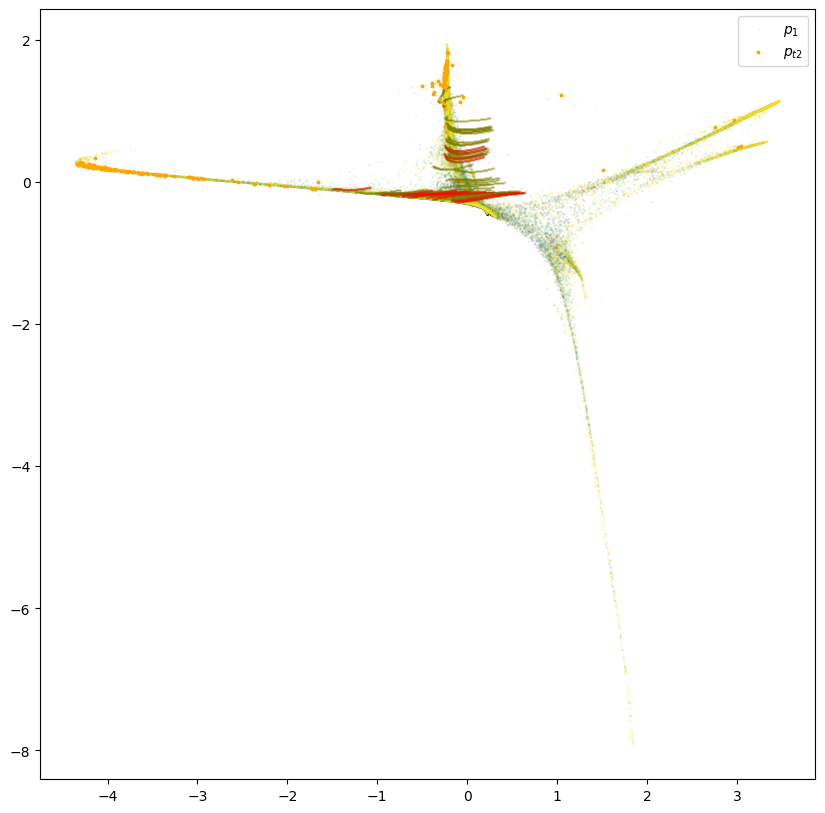

In [63]:
which_dim = [0,2]
fig, ax = plot_allcells_and_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()